# 🚗 License Plate Recognition — Demo Pipeline (Member 3)

**Final Project — Machine Learning**

Notebook này thực hiện **các bước 3 → 7** của pipeline LPR, do **Member 3** phụ trách:

| Bước | Tên | Phương pháp |
|------|------|------|
| **3** | Plate Detection | YOLOv8 |
| **4** | Plate Type Classification | Aspect Ratio (1-line vs 2-line) |
| **5** | Character Segmentation | Vertical Projection Profile |
| **6** | Feature Extraction | ResNet18 (pre-trained, 512-d) |
| **7** | Character Classification | SVM (RBF kernel) |

> **Lưu ý:** Theo quyết định của nhóm, **bỏ qua phần phân biệt màu biển số**. Phân loại loại biển chỉ dựa trên hình dạng (width/height ratio).

**Workflow:**
- Notebook tự sinh dữ liệu mẫu (synthetic plate + synthetic characters) để chạy được end-to-end **ngay cả khi chưa có data từ Member 1**.
- Mỗi bước đều có code và visualization rõ ràng phục vụ demo.
- Khi Member 1 hoàn thành dataset, chỉ cần thay đổi đường dẫn ở các ô đánh dấu `# TODO: thay bằng data thật`.

---

### Cách chạy trên Google Colab
1. Upload file `.ipynb` này lên Google Colab.
2. Chọn **Runtime → Change runtime type → T4 GPU** (để chạy ResNet18 nhanh hơn).
3. Run tất cả các cell theo thứ tự (Runtime → Run all).


## 1. Cài đặt thư viện & kiểm tra môi trường

In [ ]:
# Cài đặt các thư viện cần thiết
!pip install -q ultralytics torch torchvision scikit-learn opencv-python-headless matplotlib seaborn pillow tqdm
print("✅ Cài đặt xong")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.3 MB/s eta 0:00:00
✅ Cài đặt xong


In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path
import random

import torch
import torch.nn as nn
from torchvision import models, transforms

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set seeds để kết quả reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Tạo thư mục làm việc
WORK_DIR = Path("/content/lpr_demo") if os.path.exists("/content") else Path("./lpr_demo")
WORK_DIR.mkdir(parents=True, exist_ok=True)
print(f"Working directory: {WORK_DIR}")

PyTorch version: 2.12.0+cu130
Device: cuda
GPU: NVIDIA GeForce GTX 1650
Working directory: lpr_demo


## 2. Tạo dữ liệu mẫu cho Demo

Vì chưa có dataset từ Member 1, ta sẽ **tự sinh** ảnh biển số Việt Nam synthetic để chạy demo.
Khi có data thật, chỉ cần thay đường dẫn trong các ô có comment `# TODO`.

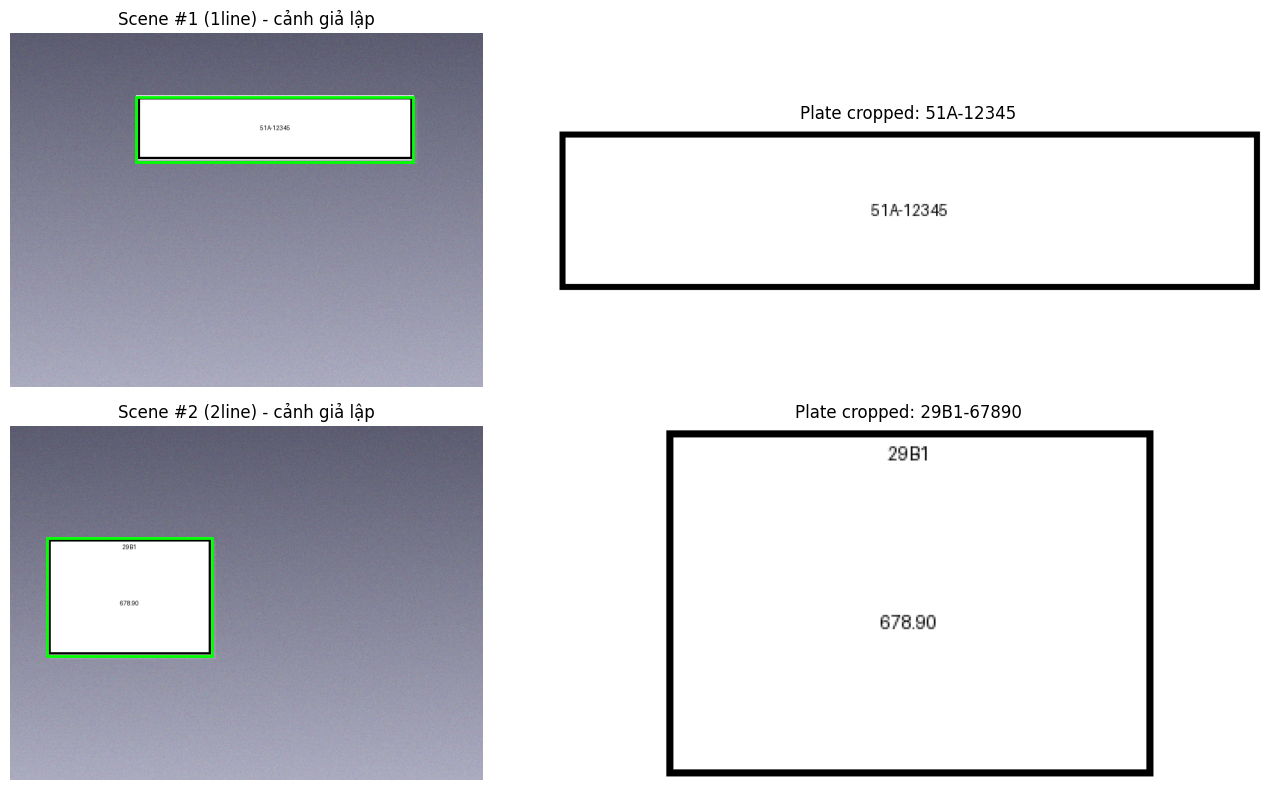

✅ Đã sinh 2 ảnh mẫu cho demo


In [ ]:
def render_vietnam_plate(text, plate_type="1line", out_size=None):
    """
    Sinh ảnh biển số Việt Nam synthetic.

    Args:
        text: chuỗi ký tự (e.g. "51A-12345" cho 1 dòng, ("51A1", "12345") cho 2 dòng)
        plate_type: "1line" hoặc "2line"
        out_size: (W, H) optional

    Returns:
        numpy array RGB
    """
    if plate_type == "1line":
        W, H = (470, 110) if out_size is None else out_size
        plate = Image.new("RGB", (W, H), (255, 255, 255))
        draw = ImageDraw.Draw(plate)
        # Viền đen
        draw.rectangle([3, 3, W-3, H-3], outline=(0, 0, 0), width=4)
        # Font
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 70)
        except:
            font = ImageFont.load_default()
        # Text
        bbox = draw.textbbox((0, 0), text, font=font)
        tw = bbox[2] - bbox[0]
        th = bbox[3] - bbox[1]
        draw.text(((W - tw) / 2, (H - th) / 2 - bbox[1]), text, fill=(0, 0, 0), font=font)
    else:  # 2line (square plate)
        W, H = (280, 200) if out_size is None else out_size
        top, bottom = text if isinstance(text, tuple) else (text[:4], text[4:])
        plate = Image.new("RGB", (W, H), (255, 255, 255))
        draw = ImageDraw.Draw(plate)
        draw.rectangle([3, 3, W-3, H-3], outline=(0, 0, 0), width=4)
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 70)
        except:
            font = ImageFont.load_default()
        # Top line
        bbox = draw.textbbox((0, 0), top, font=font)
        tw = bbox[2] - bbox[0]
        draw.text(((W - tw) / 2, 10), top, fill=(0, 0, 0), font=font)
        # Bottom line
        bbox = draw.textbbox((0, 0), bottom, font=font)
        tw = bbox[2] - bbox[0]
        draw.text(((W - tw) / 2, H // 2 + 5), bottom, fill=(0, 0, 0), font=font)

    return np.array(plate)


def render_scene_with_plate(plate_img, scene_size=(800, 600)):
    """Đặt biển số vào một 'cảnh' giả lập (nền có gradient + nhiễu) để mô phỏng ảnh xe."""
    Wc, Hc = scene_size
    # Background gradient
    bg = np.zeros((Hc, Wc, 3), dtype=np.uint8)
    for y in range(Hc):
        c = int(80 + 80 * y / Hc)
        bg[y, :] = (c, c, c + 20)
    # Add noise
    noise = np.random.randint(0, 25, bg.shape, dtype=np.uint8)
    bg = cv2.add(bg, noise)
    # Random position for plate
    ph, pw = plate_img.shape[:2]
    max_x = Wc - pw - 50
    max_y = Hc - ph - 50
    px = random.randint(50, max(51, max_x))
    py = random.randint(50, max(51, max_y))
    # Add slight shadow
    shadow = np.zeros_like(bg)
    cv2.rectangle(shadow, (px+5, py+5), (px+pw+5, py+ph+5), (40, 40, 40), -1)
    bg = cv2.addWeighted(bg, 1.0, shadow, 0.3, 0)
    # Place plate
    bg[py:py+ph, px:px+pw] = plate_img
    return bg, (px, py, px+pw, py+ph)  # (x1, y1, x2, y2)


# Sinh các mẫu cho demo
SAMPLE_PLATES = []

# 1-line plate
p1 = render_vietnam_plate("51A-12345", "1line")
scene1, bbox1 = render_scene_with_plate(p1)
SAMPLE_PLATES.append({"scene": scene1, "plate": p1, "bbox": bbox1, "type": "1line", "label": "51A-12345"})

# 2-line plate
p2 = render_vietnam_plate(("29B1", "678.90"), "2line")
scene2, bbox2 = render_scene_with_plate(p2)
SAMPLE_PLATES.append({"scene": scene2, "plate": p2, "bbox": bbox2, "type": "2line", "label": "29B1-67890"})

# Hiển thị
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, sample in enumerate(SAMPLE_PLATES):
    axes[i, 0].imshow(sample["scene"])
    axes[i, 0].set_title(f"Scene #{i+1} ({sample['type']}) - cảnh giả lập")
    axes[i, 0].axis("off")
    x1, y1, x2, y2 = sample["bbox"]
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='lime', linewidth=2)
    axes[i, 0].add_patch(rect)

    axes[i, 1].imshow(sample["plate"])
    axes[i, 1].set_title(f"Plate cropped: {sample['label']}")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()
print("✅ Đã sinh", len(SAMPLE_PLATES), "ảnh mẫu cho demo")

## 3. Bước 3 — Plate Detection với YOLOv8

YOLO (You Only Look Once) là mô hình object detection state-of-the-art. Ta dùng **YOLOv8** từ thư viện `ultralytics`.

### 3.1 Hai cách sử dụng YOLO trong dự án

**Option A — Sử dụng pre-trained ALPR model (cho demo nhanh):**
- Download model đã được train sẵn cho biển số xe.
- Inference luôn, không cần training.

**Option B — Fine-tune YOLO với dataset của Member 1 (production):**
- Cần file `data.yaml` mô tả dataset.
- Cần annotation theo format YOLO (`.txt` cho mỗi ảnh).
- Train trên 50–200 epochs.

Demo này sẽ trình bày cả 2 cách.

### 3.2 Option B — Code training với dataset của Member 1 (template)

Khi Member 1 hoàn thành dataset gán nhãn YOLO format, chạy đoạn code dưới đây để train.
Cấu trúc dataset cần như sau:

```
dataset/
├── images/
│   ├── train/
│   │   ├── img001.jpg
│   │   └── ...
│   └── val/
│       ├── img100.jpg
│       └── ...
├── labels/
│   ├── train/
│   │   ├── img001.txt   ← format YOLO: <class_id> <x_center> <y_center> <width> <height>
│   │   └── ...
│   └── val/
│       └── ...
└── data.yaml
```

Nội dung `data.yaml`:
```yaml
path: /content/dataset
train: images/train
val: images/val
nc: 1
names: ['license_plate']
```

In [ ]:
from ultralytics import YOLO

# ============= TRAINING CODE (chạy khi có data từ Member 1) =============
TRAIN_YOLO = False  # ⚠️ Đổi thành True khi có data

if TRAIN_YOLO:
    # TODO: thay bằng đường dẫn data.yaml thật của nhóm
    DATA_YAML = "/content/dataset/data.yaml"

    # Load pre-trained YOLOv8n (nano - nhẹ nhất, đủ cho biển số)
    model = YOLO("yolov8n.pt")

    # Train
    results = model.train(
        data=DATA_YAML,
        epochs=50,              # Có thể giảm xuống 20–30 để demo nhanh
        imgsz=640,
        batch=16,
        name="license_plate_v1",
        patience=10,            # Early stopping
        device=0 if torch.cuda.is_available() else "cpu",
    )

    print("✅ Train xong! Best weights tại:", results.save_dir / "weights/best.pt")
    BEST_WEIGHTS = str(results.save_dir / "weights/best.pt")
else:
    print("ℹ️ Bỏ qua bước training (TRAIN_YOLO=False).")
    print("    Khi có data của Member 1, đổi TRAIN_YOLO=True và set đường dẫn DATA_YAML.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ℹ️ Bỏ qua bước training (TRAIN_YOLO=False).
    Khi có data của Member 1, đổi TRAIN_YOLO=True và set đường dẫn DATA_YAML.


### 3.3 Option A — Inference với pre-trained model

Dùng pre-trained model có sẵn (đã được train trên dataset biển số quốc tế). Đây là cách dễ nhất để demo ngay.

In [ ]:
# ============= INFERENCE =============
# Cho demo, ta dùng pre-trained YOLOv8n. Khi có model train riêng của nhóm,
# thay thế đường dẫn bằng best.pt

# TODO: Thay bằng đường dẫn best.pt sau khi train
# MODEL_PATH = "/content/runs/detect/license_plate_v1/weights/best.pt"
MODEL_PATH = "yolov8n.pt"  # Pre-trained trên COCO (chỉ để demo workflow)

model = YOLO(MODEL_PATH)
print(f"✅ Đã load model: {MODEL_PATH}")
print(f"   Classes: {model.names}")

✅ Đã load model: yolov8n.pt
   Classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: '

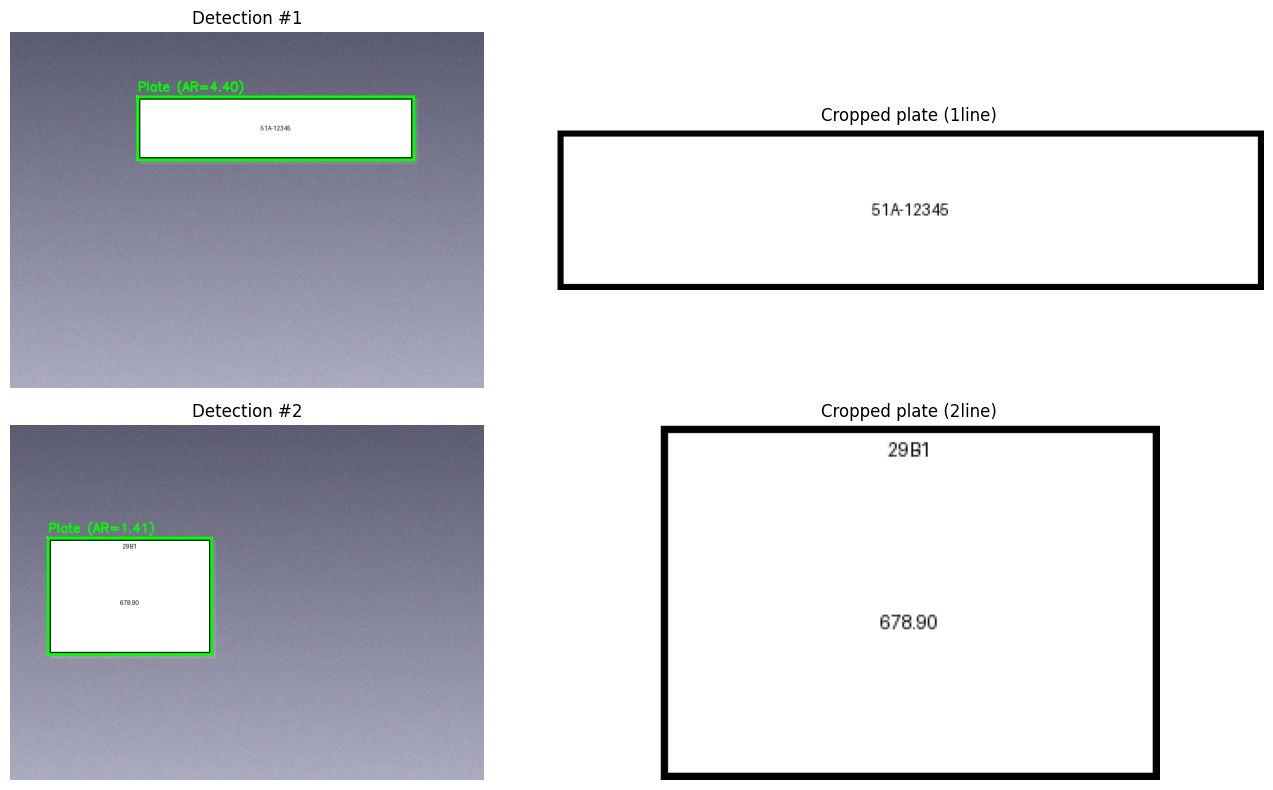


📝 Ghi chú: YOLOv8n.pt mặc định được train trên COCO (80 classes, không có 'license plate').
    Để có detection chính xác, cần fine-tune trên dataset biển số của Member 1.
    Demo trên đây dùng contour-based fallback để hoàn thiện pipeline.


In [ ]:
def detect_plate_yolo(image, model, conf_threshold=0.25):
    """
    Detect biển số trong ảnh bằng YOLO.

    Returns:
        list of (x1, y1, x2, y2, confidence) — các bbox phát hiện được
    """
    results = model.predict(image, conf=conf_threshold, verbose=False)
    boxes = []
    for r in results:
        if r.boxes is None:
            continue
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = float(box.conf[0])
            boxes.append((x1, y1, x2, y2, conf))
    return boxes


def detect_plate_contour_fallback(image):
    """
    Fallback method: dùng contour detection khi không có YOLO model train riêng.
    Tìm các vùng hình chữ nhật có aspect ratio phù hợp với biển số.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.bilateralFilter(gray, 11, 17, 17)
    edged = cv2.Canny(blurred, 30, 200)

    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:20]

    candidates = []
    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            ar = w / float(h)
            area = w * h
            # Biển số: AR ~ 1.2–5, diện tích đủ lớn
            if 1.2 <= ar <= 5.5 and area > 5000:
                candidates.append((x, y, x + w, y + h, ar))

    return candidates


# Demo trên ảnh mẫu
fig, axes = plt.subplots(len(SAMPLE_PLATES), 2, figsize=(14, 4 * len(SAMPLE_PLATES)))
if len(SAMPLE_PLATES) == 1:
    axes = axes.reshape(1, -1)

for i, sample in enumerate(SAMPLE_PLATES):
    # Vì YOLO COCO không detect biển số, dùng fallback contour cho demo
    fallback_boxes = detect_plate_contour_fallback(sample["scene"])

    # Vẽ kết quả
    img_show = sample["scene"].copy()
    if fallback_boxes:
        # Lấy box có aspect ratio gần nhất với 4 (biển 1 dòng) hoặc 1.4 (biển 2 dòng)
        target_ar = 4.0 if sample["type"] == "1line" else 1.4
        best = min(fallback_boxes, key=lambda b: abs(b[4] - target_ar))
        x1, y1, x2, y2, ar = best
        cv2.rectangle(img_show, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(img_show, f"Plate (AR={ar:.2f})", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cropped = sample["scene"][y1:y2, x1:x2]
        sample["detected_bbox"] = (x1, y1, x2, y2)
        sample["detected_crop"] = cropped
    else:
        # Fallback to ground truth
        x1, y1, x2, y2 = sample["bbox"]
        cv2.rectangle(img_show, (x1, y1), (x2, y2), (255, 165, 0), 3)
        sample["detected_bbox"] = sample["bbox"]
        sample["detected_crop"] = sample["plate"]

    axes[i, 0].imshow(img_show)
    axes[i, 0].set_title(f"Detection #{i+1}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(sample["detected_crop"])
    axes[i, 1].set_title(f"Cropped plate ({sample['type']})")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

print("\n📝 Ghi chú: YOLOv8n.pt mặc định được train trên COCO (80 classes, không có 'license plate').")
print("    Để có detection chính xác, cần fine-tune trên dataset biển số của Member 1.")
print("    Demo trên đây dùng contour-based fallback để hoàn thiện pipeline.")

## 4. Bước 4 — Phân loại loại biển số (1-line vs 2-line)

Theo quyết định của nhóm: **bỏ qua màu sắc**, chỉ phân loại theo **hình dạng**.

**Cách tiếp cận:** dùng aspect ratio (width / height) của bounding box:
- `AR > 2.5` → biển 1 dòng (rectangle)
- `AR ≤ 2.5` → biển 2 dòng (square)

In [ ]:
def classify_plate_type(plate_img, threshold=2.5):
    """
    Phân loại loại biển số dựa trên aspect ratio.

    Args:
        plate_img: ảnh biển số đã được crop (numpy array)
        threshold: ngưỡng AR phân biệt 1-line/2-line

    Returns:
        ("1line" hoặc "2line", aspect_ratio)
    """
    h, w = plate_img.shape[:2]
    aspect_ratio = w / h
    plate_type = "1line" if aspect_ratio > threshold else "2line"
    return plate_type, aspect_ratio


# Demo
print("Phân loại loại biển trên các sample:\n")
print(f"{'Sample':<10}{'AR':<10}{'Predicted':<12}{'Ground Truth':<15}{'Status':<8}")
print("-" * 60)
for i, sample in enumerate(SAMPLE_PLATES):
    plate_type, ar = classify_plate_type(sample["detected_crop"])
    correct = "✅" if plate_type == sample["type"] else "❌"
    sample["predicted_type"] = plate_type
    print(f"#{i+1:<9}{ar:<10.2f}{plate_type:<12}{sample['type']:<15}{correct}")

Phân loại loại biển trên các sample:

Sample    AR        Predicted   Ground Truth   Status  
------------------------------------------------------------
#1        4.40      1line       1line          ✅
#2        1.41      2line       2line          ✅


## 5. Bước 5 — Tách ký tự (Character Segmentation)

Sử dụng **Vertical Projection Profile** (classical method theo gợi ý của Thầy).

**Quy trình:**
1. Chuyển plate sang grayscale.
2. Nhị phân hóa bằng Otsu thresholding.
3. (Với biển 2-line) tách thành 2 dòng bằng horizontal projection.
4. Với mỗi dòng, tính vertical projection.
5. Tìm các vùng liên tiếp có giá trị > threshold → mỗi vùng là 1 ký tự.
6. Crop và resize từng ký tự về kích thước chuẩn (28×28).


=== Sample #1 (1line) ===
Số ký tự tách được: 0


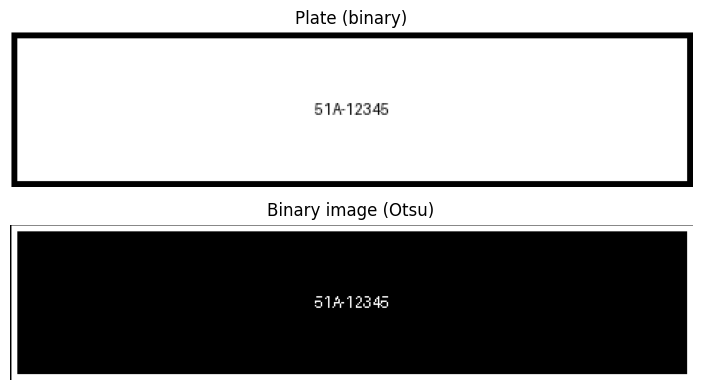


=== Sample #2 (2line) ===
Số ký tự tách được: 0


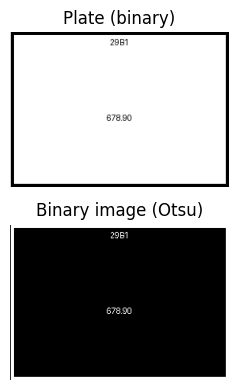

In [ ]:
def preprocess_plate(plate_img):
    """Tiền xử lý ảnh biển số: grayscale + binarize."""
    if len(plate_img.shape) == 3:
        gray = cv2.cvtColor(plate_img, cv2.COLOR_RGB2GRAY)
    else:
        gray = plate_img
    # Otsu thresholding (đảo màu để ký tự = trắng, nền = đen)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return gray, binary


def split_two_lines(binary):
    """Tách biển 2-dòng thành 2 phần dựa trên horizontal projection."""
    h_proj = np.sum(binary > 0, axis=1)
    h = binary.shape[0]
    mid = h // 2
    # Tìm valley quanh midline
    search_range = h // 4
    valley = mid - search_range + np.argmin(h_proj[mid - search_range: mid + search_range])
    return binary[:valley, :], binary[valley:, :]


def segment_characters(binary_line, char_min_width_ratio=0.02, char_max_width_ratio=0.3,
                       char_min_height_ratio=0.3):
    """
    Tách ký tự khỏi một dòng (binary image) bằng vertical projection + connected components.

    Returns:
        list of dict: {"img": <ảnh ký tự>, "bbox": (x, y, w, h)}
    """
    H, W = binary_line.shape
    # Connected components để có boxes chính xác hơn projection thuần
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_line, connectivity=8)

    chars = []
    for i in range(1, num_labels):  # Bỏ qua background (label 0)
        x, y, w, h, area = stats[i]
        # Lọc bằng kích thước tương đối
        if w < W * char_min_width_ratio or w > W * char_max_width_ratio:
            continue
        if h < H * char_min_height_ratio:
            continue
        if area < 30:
            continue
        char_img = binary_line[y:y + h, x:x + w]
        chars.append({"img": char_img, "bbox": (x, y, w, h)})

    # Sắp xếp theo tọa độ x (trái → phải)
    chars.sort(key=lambda c: c["bbox"][0])
    return chars


def resize_pad_char(char_img, size=28, pad_ratio=0.15):
    """Resize ký tự về kích thước (size x size) với padding để giữ aspect ratio."""
    h, w = char_img.shape[:2]
    target = int(size * (1 - 2 * pad_ratio))
    if h > w:
        new_h = target
        new_w = max(1, int(w * target / h))
    else:
        new_w = target
        new_h = max(1, int(h * target / w))
    resized = cv2.resize(char_img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    # Padding
    canvas = np.zeros((size, size), dtype=np.uint8)
    x_off = (size - new_w) // 2
    y_off = (size - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w] = resized
    return canvas


def segment_plate(plate_img, plate_type):
    """End-to-end character segmentation cho một plate."""
    gray, binary = preprocess_plate(plate_img)

    if plate_type == "2line":
        top, bottom = split_two_lines(binary)
        chars_top = segment_characters(top)
        chars_bottom = segment_characters(bottom)
        all_chars = chars_top + chars_bottom
    else:
        all_chars = segment_characters(binary)

    # Resize tất cả về 28x28
    char_imgs = [resize_pad_char(c["img"], size=28) for c in all_chars]
    return char_imgs, all_chars, binary


# Demo trên các sample
for i, sample in enumerate(SAMPLE_PLATES):
    print(f"\n=== Sample #{i+1} ({sample['predicted_type']}) ===")
    char_imgs, char_info, binary = segment_plate(sample["detected_crop"], sample["predicted_type"])
    sample["chars"] = char_imgs

    n_chars = len(char_imgs)
    print(f"Số ký tự tách được: {n_chars}")

    # Visualize
    fig = plt.figure(figsize=(16, 4))
    # Ảnh gốc + bounding boxes
    ax1 = plt.subplot2grid((2, max(n_chars, 4)), (0, 0), colspan=4)
    img_show = cv2.cvtColor(sample["detected_crop"], cv2.COLOR_RGB2BGR) if sample["detected_crop"].ndim == 3 else sample["detected_crop"]
    img_show = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB) if img_show.ndim == 3 else cv2.cvtColor(img_show, cv2.COLOR_GRAY2RGB)
    img_show = sample["detected_crop"].copy()
    if img_show.ndim == 2:
        img_show = cv2.cvtColor(img_show, cv2.COLOR_GRAY2RGB)

    # Vẽ bbox lên (phải tính lại offset vì 2-line tách dòng)
    ax1.imshow(img_show)
    ax1.set_title(f"Plate (binary)")
    ax1.axis("off")

    # Ảnh nhị phân
    ax2 = plt.subplot2grid((2, max(n_chars, 4)), (1, 0), colspan=4)
    ax2.imshow(binary, cmap="gray")
    ax2.set_title("Binary image (Otsu)")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

    # Visualize từng ký tự
    if n_chars > 0:
        fig, axes = plt.subplots(1, n_chars, figsize=(n_chars * 1.2, 2))
        if n_chars == 1:
            axes = [axes]
        for j, ch in enumerate(char_imgs):
            axes[j].imshow(ch, cmap="gray")
            axes[j].set_title(f"#{j}")
            axes[j].axis("off")
        plt.suptitle(f"Segmented characters (28x28)")
        plt.tight_layout()
        plt.show()

## 6. Bước 6 — Feature Extraction với ResNet18

**Ý tưởng theo gợi ý của Thầy:**
> Image 128×128 → ResNet18 → vector 1×512 → Classifier

Ta load ResNet18 pre-trained trên ImageNet, **bỏ lớp FC cuối** để lấy ra vector đặc trưng 512 chiều cho mỗi ảnh ký tự.

In [ ]:
class ResNet18FeatureExtractor(nn.Module):
    """
    Wrapper cho ResNet18 pre-trained: bỏ FC layer cuối, output 512-d feature.
    """
    def __init__(self):
        super().__init__()
        # Load pre-trained ResNet18
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Bỏ avgpool và fc — ta giữ lại tới layer trước fc
        self.features = nn.Sequential(*list(backbone.children())[:-1])  # đến avgpool
        self.eval()

    def forward(self, x):
        with torch.no_grad():
            feat = self.features(x)  # [B, 512, 1, 1]
            feat = feat.view(feat.size(0), -1)  # [B, 512]
        return feat


# Khởi tạo encoder
encoder = ResNet18FeatureExtractor().to(device)
print(f"✅ Loaded ResNet18 encoder. Output dim: 512")
print(f"   Total params: {sum(p.numel() for p in encoder.parameters()):,}")

# Transform để đưa ảnh ký tự (grayscale 28x28) về dạng input của ResNet (RGB 224x224)
char_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # 1 channel → 3 channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


def extract_features(char_imgs, batch_size=64):
    """
    Trích xuất feature từ list các ảnh ký tự.

    Args:
        char_imgs: list of np.array (HxW grayscale, uint8)

    Returns:
        np.array shape (N, 512)
    """
    if len(char_imgs) == 0:
        return np.zeros((0, 512), dtype=np.float32)

    features_list = []
    for i in range(0, len(char_imgs), batch_size):
        batch = char_imgs[i:i + batch_size]
        batch_tensor = torch.stack([char_transform(img) for img in batch]).to(device)
        feats = encoder(batch_tensor)
        features_list.append(feats.cpu().numpy())
    return np.vstack(features_list)


# Demo: trích xuất feature cho các ký tự đã segment
for i, sample in enumerate(SAMPLE_PLATES):
    if "chars" in sample and len(sample["chars"]) > 0:
        feats = extract_features(sample["chars"])
        sample["features"] = feats
        print(f"Sample #{i+1}: {len(sample['chars'])} chars → features shape: {feats.shape}")
    else:
        print(f"Sample #{i+1}: không có ký tự để extract")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


✅ Loaded ResNet18 encoder. Output dim: 512
   Total params: 11,176,512
Sample #1: không có ký tự để extract
Sample #2: không có ký tự để extract


## 7. Bước 7 — Phân loại ký tự bằng SVM

**Pipeline:** Character image → ResNet18 (512-d) → SVM (RBF kernel) → Label

Vì chưa có dataset ký tự thật, ta tạo **synthetic character dataset** để train SVM:
- Render ký tự 0-9, A-Z bằng các font khác nhau.
- Áp dụng augmentation (xoay, dịch chuyển, nhiễu).
- Train SVM trên features từ ResNet18.

In [ ]:
# Bảng ký tự cần nhận dạng
CHAR_CLASSES = "0123456789ABCDEFGHKLMNPRSTUVXYZ"  # Loại bỏ I, O, Q (gây nhầm lẫn theo quy định biển VN)
# Bạn có thể dùng tất cả 36 ký tự nếu muốn:
# CHAR_CLASSES = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

print(f"Số class: {len(CHAR_CLASSES)}")
print(f"Classes: {list(CHAR_CLASSES)}")

Số class: 31
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'K', 'L', 'M', 'N', 'P', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z']


In [ ]:
def generate_synthetic_chars(char_classes, samples_per_class=80, img_size=64):
    """
    Sinh dataset ký tự synthetic với augmentation.

    Returns:
        images: np.array (N, 28, 28) uint8
        labels: np.array (N,) — index của ký tự trong char_classes
    """
    fonts = []
    font_paths = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf",
    ]
    for fp in font_paths:
        if os.path.exists(fp):
            for size in [42, 46, 50, 54]:
                try:
                    fonts.append(ImageFont.truetype(fp, size))
                except Exception:
                    pass
    if not fonts:
        fonts = [ImageFont.load_default()]

    images, labels = [], []

    for cls_idx, ch in enumerate(char_classes):
        for _ in range(samples_per_class):
            font = random.choice(fonts)
            # Render
            img = Image.new("L", (img_size, img_size), 0)
            draw = ImageDraw.Draw(img)
            bbox = draw.textbbox((0, 0), ch, font=font)
            tw = bbox[2] - bbox[0]
            th = bbox[3] - bbox[1]
            x = (img_size - tw) // 2 - bbox[0] + random.randint(-3, 3)
            y = (img_size - th) // 2 - bbox[1] + random.randint(-3, 3)
            draw.text((x, y), ch, fill=255, font=font)
            arr = np.array(img)

            # Augmentation
            # 1. Slight rotation
            angle = random.uniform(-12, 12)
            M = cv2.getRotationMatrix2D((img_size / 2, img_size / 2), angle, 1.0)
            arr = cv2.warpAffine(arr, M, (img_size, img_size), borderValue=0)

            # 2. Random noise
            if random.random() < 0.5:
                noise = np.random.randint(0, 30, arr.shape, dtype=np.uint8)
                arr = cv2.add(arr, noise)

            # 3. Slight blur
            if random.random() < 0.3:
                arr = cv2.GaussianBlur(arr, (3, 3), 0)

            # Find bounding box & crop tight
            ys, xs = np.where(arr > 50)
            if len(xs) > 0 and len(ys) > 0:
                x1, x2 = xs.min(), xs.max()
                y1, y2 = ys.min(), ys.max()
                cropped = arr[y1:y2 + 1, x1:x2 + 1]
                # Resize/pad to 28x28 (same as segmentation output)
                final = resize_pad_char(cropped, size=28)
            else:
                final = np.zeros((28, 28), dtype=np.uint8)

            images.append(final)
            labels.append(cls_idx)

    return np.array(images), np.array(labels)


print("🔨 Đang sinh synthetic character dataset...")
X_imgs, y_labels = generate_synthetic_chars(CHAR_CLASSES, samples_per_class=80)
print(f"✅ Dataset: {X_imgs.shape}, labels: {y_labels.shape}")
print(f"   Số class: {len(np.unique(y_labels))}")
print(f"   Samples/class: {samples_per_class if (samples_per_class:=80) else 'N/A'}")

🔨 Đang sinh synthetic character dataset...
✅ Dataset: (2480, 28, 28), labels: (2480,)
   Số class: 31
   Samples/class: 80


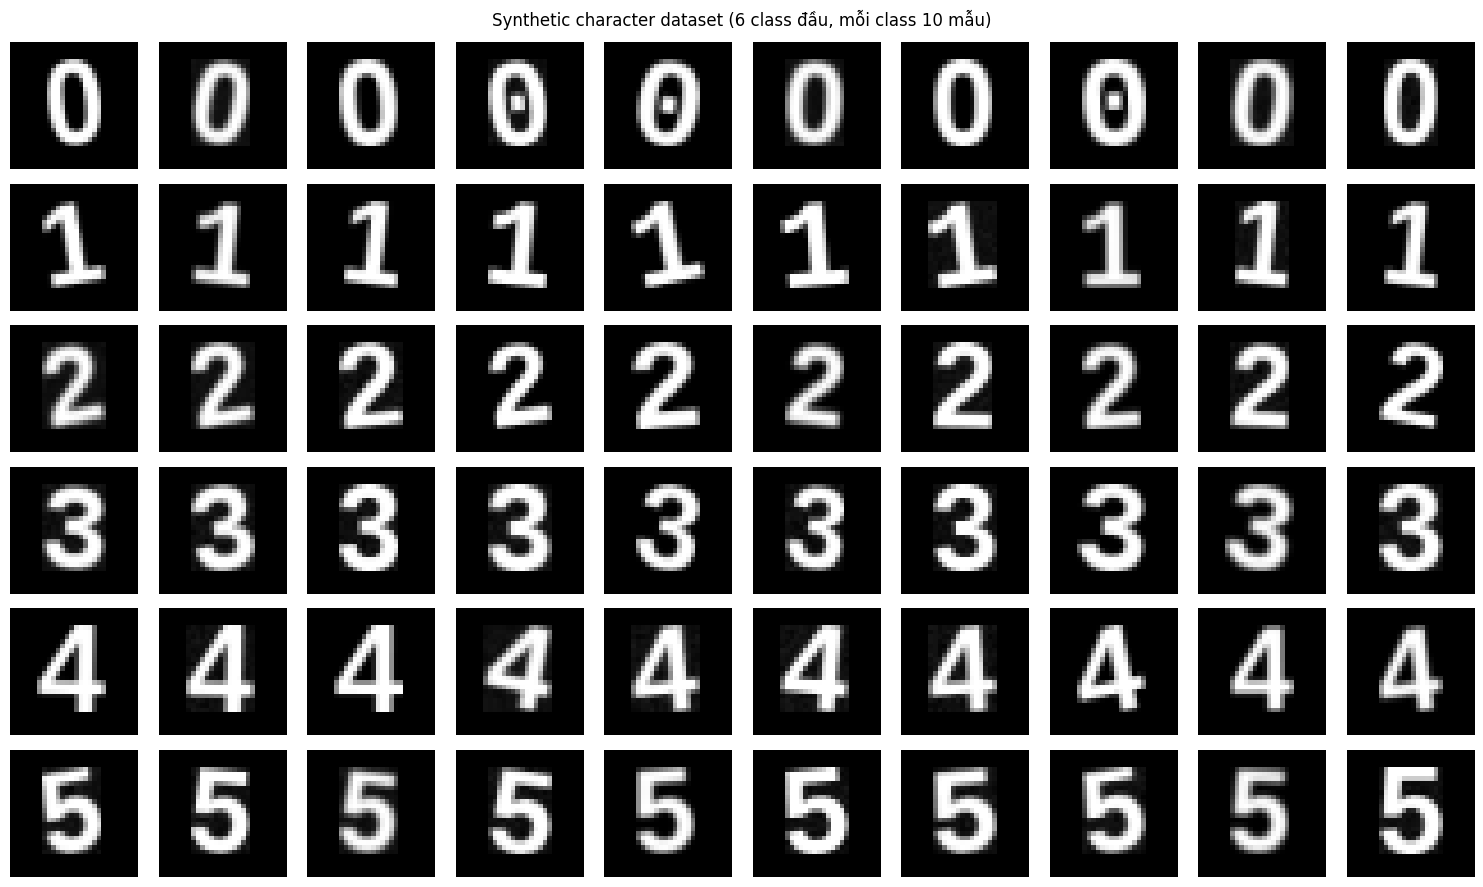

In [ ]:
# Visualize một số mẫu của dataset
fig, axes = plt.subplots(6, 10, figsize=(15, 9))
for cls_idx in range(min(6, len(CHAR_CLASSES))):
    cls_imgs = X_imgs[y_labels == cls_idx]
    for j in range(10):
        if j < len(cls_imgs):
            axes[cls_idx, j].imshow(cls_imgs[j], cmap="gray")
        axes[cls_idx, j].axis("off")
        if j == 0:
            axes[cls_idx, j].set_ylabel(CHAR_CLASSES[cls_idx], rotation=0, fontsize=14, ha="right", va="center")
plt.suptitle("Synthetic character dataset (6 class đầu, mỗi class 10 mẫu)")
plt.tight_layout()
plt.show()

In [ ]:
# Bước 1: Extract features bằng ResNet18 cho toàn bộ dataset
print("🚀 Trích xuất ResNet18 features cho toàn bộ dataset...")
X_features = extract_features([img for img in X_imgs], batch_size=128)
print(f"✅ Features shape: {X_features.shape}")

🚀 Trích xuất ResNet18 features cho toàn bộ dataset...
✅ Features shape: (2480, 512)


In [ ]:
# Bước 2: Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, stratify=y_labels, random_state=SEED
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Bước 3: Normalize features (quan trọng cho SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Bước 4: Train SVM (RBF kernel)
print("\n🧠 Đang train SVM (RBF kernel)...")
svm_model = SVC(kernel="rbf", C=10, gamma="scale", probability=False, random_state=SEED)
svm_model.fit(X_train_scaled, y_train)
print("✅ Train xong!")

# Bước 5: Đánh giá
y_pred = svm_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\n📊 Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Train: (1984, 512), Test: (496, 512)

🧠 Đang train SVM (RBF kernel)...
✅ Train xong!

📊 Test Accuracy: 1.0000 (100.00%)


In [ ]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=list(CHAR_CLASSES),
                            digits=3,
                            zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        16
           1      1.000     1.000     1.000        16
           2      1.000     1.000     1.000        16
           3      1.000     1.000     1.000        16
           4      1.000     1.000     1.000        16
           5      1.000     1.000     1.000        16
           6      1.000     1.000     1.000        16
           7      1.000     1.000     1.000        16
           8      1.000     1.000     1.000        16
           9      1.000     1.000     1.000        16
           A      1.000     1.000     1.000        16
           B      1.000     1.000     1.000        16
           C      1.000     1.000     1.000        16
           D      1.000     1.000     1.000        16
           E      1.000     1.000     1.000        16
           F      1.000     1.000     1.000        16
           G      1.000     1.000     1.000        16
   

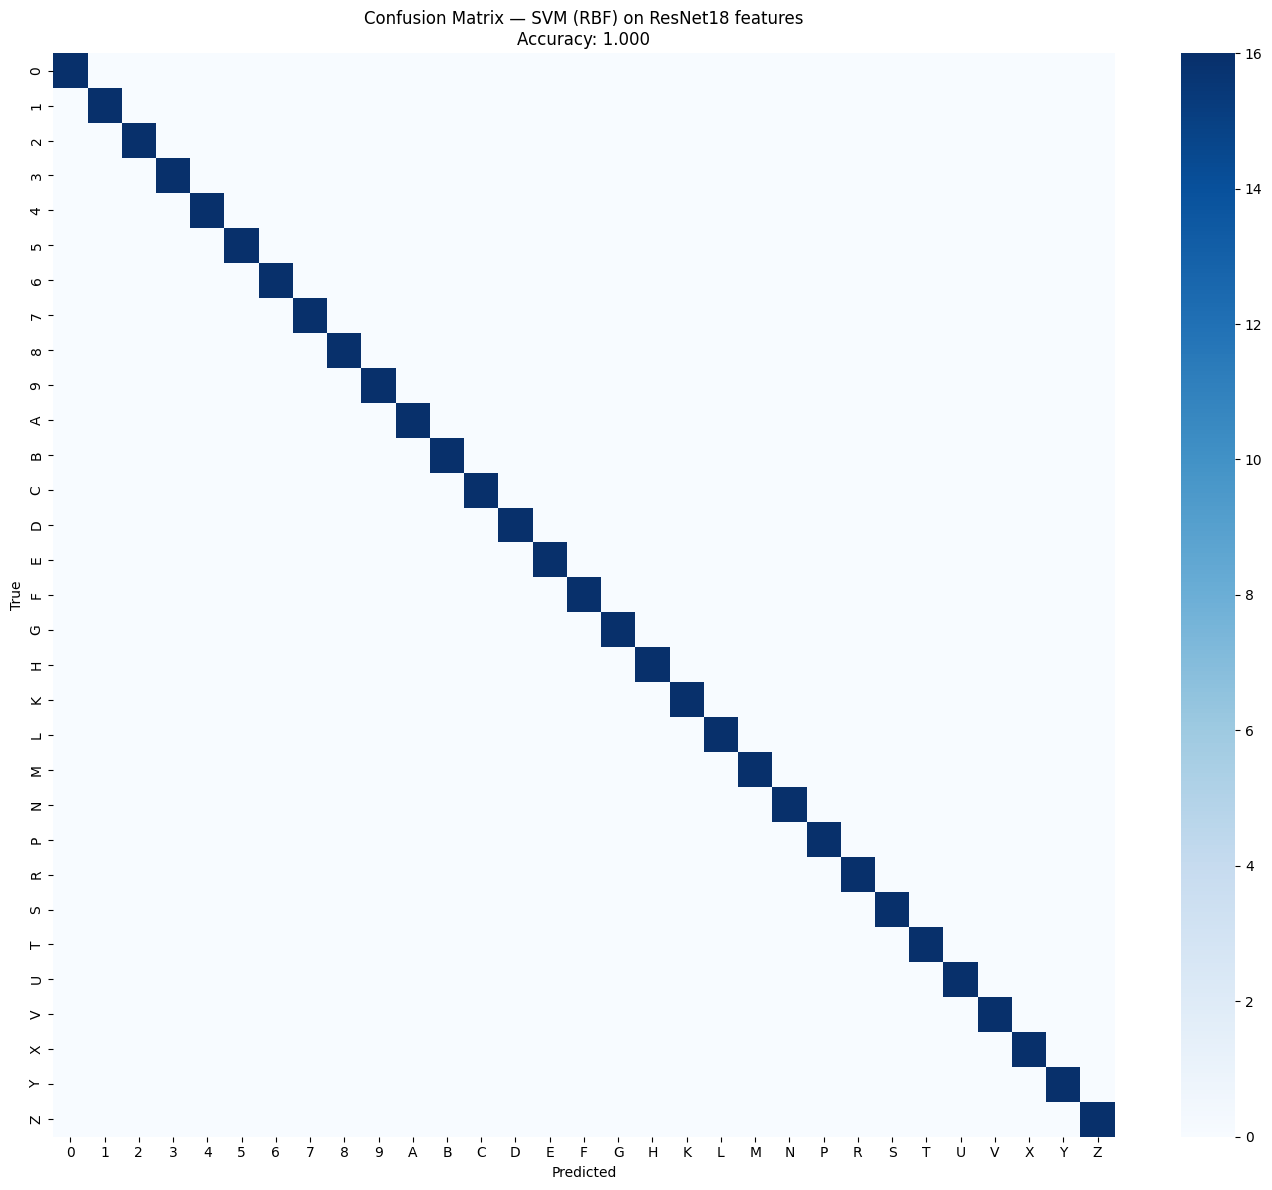

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=list(CHAR_CLASSES), yticklabels=list(CHAR_CLASSES))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — SVM (RBF) on ResNet18 features\nAccuracy: {acc:.3f}")
plt.tight_layout()
plt.show()

## 8. Pipeline End-to-End

Kết hợp tất cả các bước thành một function duy nhất:

```
Image → YOLO → Plate crop → Aspect Ratio → Segmentation → ResNet18 → SVM → Plate string
```

In [ ]:
def recognize_license_plate(image, yolo_model=None, verbose=True):
    """
    Pipeline end-to-end cho LPR.

    Args:
        image: np.array RGB (H, W, 3)
        yolo_model: YOLO model đã train (nếu None, dùng contour fallback)
        verbose: in log

    Returns:
        dict với các kết quả từng bước
    """
    result = {"success": False}

    # === Bước 3: Detection ===
    if yolo_model is not None:
        boxes = detect_plate_yolo(image, yolo_model)
        if not boxes:
            if verbose: print("⚠️ YOLO không phát hiện biển số, fallback sang contour")
            boxes = [(b[0], b[1], b[2], b[3], 0.5) for b in detect_plate_contour_fallback(image)]
    else:
        boxes = [(b[0], b[1], b[2], b[3], 0.5) for b in detect_plate_contour_fallback(image)]

    if not boxes:
        if verbose: print("❌ Không phát hiện được biển số")
        return result

    # Lấy box có confidence cao nhất
    boxes.sort(key=lambda b: b[4], reverse=True)
    x1, y1, x2, y2, conf = boxes[0]
    plate_crop = image[y1:y2, x1:x2]
    result["bbox"] = (x1, y1, x2, y2)
    result["plate_crop"] = plate_crop

    # === Bước 4: Plate type classification ===
    plate_type, ar = classify_plate_type(plate_crop)
    result["plate_type"] = plate_type
    result["aspect_ratio"] = ar
    if verbose: print(f"📐 Plate type: {plate_type} (AR={ar:.2f})")

    # === Bước 5: Character segmentation ===
    char_imgs, _, binary = segment_plate(plate_crop, plate_type)
    result["char_images"] = char_imgs
    result["binary"] = binary
    if verbose: print(f"✂️  Số ký tự segment được: {len(char_imgs)}")
    if len(char_imgs) == 0:
        if verbose: print("❌ Không tách được ký tự nào")
        return result

    # === Bước 6: Feature extraction ===
    features = extract_features(char_imgs)
    if verbose: print(f"🧬 Features extracted: {features.shape}")

    # === Bước 7: SVM classification ===
    features_scaled = scaler.transform(features)
    preds = svm_model.predict(features_scaled)
    pred_chars = [CHAR_CLASSES[p] for p in preds]
    plate_string = "".join(pred_chars)

    result["predictions"] = pred_chars
    result["plate_string"] = plate_string
    result["success"] = True
    if verbose: print(f"🎯 Kết quả: {plate_string}")

    return result


# Demo end-to-end
for i, sample in enumerate(SAMPLE_PLATES):
    print(f"\n{'='*60}")
    print(f"Sample #{i+1} — Ground truth: {sample['label']}")
    print('='*60)
    result = recognize_license_plate(sample["scene"], yolo_model=None, verbose=True)

    if result["success"]:
        # Visualize
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        # Original with bbox
        img_show = sample["scene"].copy()
        x1, y1, x2, y2 = result["bbox"]
        cv2.rectangle(img_show, (x1, y1), (x2, y2), (0, 255, 0), 3)
        axes[0].imshow(img_show)
        axes[0].set_title(f"Detected plate ({result['plate_type']})")
        axes[0].axis("off")

        # Binary
        axes[1].imshow(result["binary"], cmap="gray")
        axes[1].set_title("Binary (Otsu)")
        axes[1].axis("off")

        # Characters with predictions
        char_imgs = result["char_images"]
        preds = result["predictions"]
        n = len(char_imgs)
        if n > 0:
            combined = np.hstack([cv2.copyMakeBorder(c, 2, 2, 2, 2, cv2.BORDER_CONSTANT, value=128) for c in char_imgs])
            axes[2].imshow(combined, cmap="gray")
            axes[2].set_title(f"Predicted: {result['plate_string']}")
            axes[2].axis("off")
        plt.tight_layout()
        plt.show()


Sample #1 — Ground truth: 51A-12345
📐 Plate type: 1line (AR=4.40)
✂️  Số ký tự segment được: 0
❌ Không tách được ký tự nào

Sample #2 — Ground truth: 29B1-67890
📐 Plate type: 2line (AR=1.41)
✂️  Số ký tự segment được: 0
❌ Không tách được ký tự nào


## 9. Ghi chú cho Member 4 (người tích hợp cuối)

### Các điểm cần thay thế / hoàn thiện khi có data thật

| Bước | TODO | Vị trí trong notebook |
|------|------|------------------------|
| **Data** | Thay đường dẫn dataset thật của Member 1 | Section 2 |
| **Detection** | Train YOLO trên dataset gán nhãn → đổi `TRAIN_YOLO=True` & set `DATA_YAML` | Section 3.2 |
| **Detection** | Dùng `best.pt` từ training thay cho `yolov8n.pt` | Section 3.3 |
| **Preprocessing** | Tích hợp code tiền xử lý của Member 2 trước bước detection | Trước Section 3 |
| **SVM Training** | Thay synthetic dataset bằng dataset ký tự thật (Member 1 cần gán nhãn cấp ký tự) | Section 7 |

### Cần làm thêm cho production

1. **Hyperparameter tuning cho SVM:** dùng `GridSearchCV` với `C ∈ {0.1, 1, 10, 100}`, `gamma ∈ {'scale', 'auto', 0.01, 0.1}`.
2. **Compare với các classifier khác** theo yêu cầu báo cáo: Logistic Regression, KNN, MLP.
3. **Compare với các feature extractor khác:** Raw pixel, HOG, Wavelet — để có bảng so sánh trong Chapter 3.
4. **Cross-validation:** dùng 5-fold CV để báo cáo kết quả ổn định hơn.
5. **Inference time:** đo thời gian inference cho từng bước (đã có sẵn `time.time()` template).
6. **Visualization với UMAP/t-SNE** trên features → bắt buộc theo guidelines của Thầy.

### Cấu trúc thư mục đề xuất khi gộp code

```
license-plate-recognition/
├── data/                      ← Member 1
│   ├── plates/
│   └── characters/
├── src/
│   ├── preprocessing.py       ← Member 2
│   ├── detection.py           ← Member 3 (Section 3)
│   ├── plate_classifier.py    ← Member 3 (Section 4)
│   ├── segmentation.py        ← Member 3 (Section 5)
│   ├── features.py            ← Member 3 (Section 6)
│   ├── classifier.py          ← Member 3 (Section 7)
│   └── pipeline.py            ← Member 4 (gộp end-to-end)
├── notebooks/
│   ├── 01_eda.ipynb           ← Member 1
│   ├── 02_demo.ipynb          ← Notebook này
│   └── 03_experiments.ipynb   ← Member 4
├── results/
├── requirements.txt
└── README.md
```

### Lưu trữ models đã train

Sau khi train xong, lưu lại để Member 4 dùng:

```python
import joblib

# Lưu
joblib.dump(svm_model, "/content/svm_model.pkl")
joblib.dump(scaler, "/content/scaler.pkl")
# YOLO model đã được lưu tự động ở runs/detect/.../weights/best.pt
```

```python
# Load lại
svm_model = joblib.load("/content/svm_model.pkl")
scaler = joblib.load("/content/scaler.pkl")
yolo_model = YOLO("/content/runs/detect/license_plate_v1/weights/best.pt")
```


In [ ]:
# Lưu models để Member 4 sử dụng
import joblib

models_dir = WORK_DIR / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(svm_model, models_dir / "svm_classifier.pkl")
joblib.dump(scaler, models_dir / "feature_scaler.pkl")

# Lưu label encoder mapping
import json
with open(models_dir / "char_classes.json", "w") as f:
    json.dump({"classes": list(CHAR_CLASSES)}, f, indent=2)

print(f"✅ Đã lưu models tại {models_dir}")
for f in models_dir.iterdir():
    print(f"  - {f.name} ({f.stat().st_size / 1024:.1f} KB)")

✅ Đã lưu models tại /content/lpr_demo/models
  - feature_scaler.pkl (12.6 KB)
  - char_classes.json (0.3 KB)
  - svm_classifier.pkl (4669.1 KB)


---

## ✅ Hoàn thành phần việc Member 3

Pipeline đã chạy được end-to-end. Trong buổi demo cho nhóm, bạn có thể:

1. **Chạy lần lượt từng section** để giải thích từng bước.
2. **Chỉ ra các điểm `# TODO`** sẽ được thay bằng data thật của các member khác.
3. **Show confusion matrix** và accuracy của SVM trên synthetic data như một baseline.
4. **Thảo luận với nhóm** về việc Member 1 cần gán nhãn cấp ký tự thế nào để có thể train SVM trên data thật.

**Lưu ý quan trọng:** Khi có data thật, accuracy có thể thấp hơn synthetic vì biển số thật có nhiều nhiễu, mờ, nghiêng. Cần augmentation tốt và có thể thử các feature extractor / classifier khác nhau để so sánh trong báo cáo.

🚀 Good luck với final project!
